# Experiment 5: Fraud Detection using SMOTE

### Aim:
To improve fraud detection performance by handling class imbalance using SMOTE (Synthetic Minority Over-sampling Technique).

### Objective:
To apply SMOTE on the training dataset and compare model performance before and after resampling.

### Theory:
Fraud datasets are highly imbalanced, where fraudulent transactions are significantly fewer than legitimate ones.

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples of the minority class to balance the dataset.

By balancing the dataset, the model can better learn fraud patterns and improve recall and F1-score.


In [2]:
# Run once if not installed
!pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTE


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv("data/online_fraud.csv")

# Sample for faster processing
df = df.sample(n=100000, random_state=42)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (100000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


In [4]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)

df = pd.get_dummies(df, columns=['type'], drop_first=True)

X = df.drop('isFraud', axis=1)
y = df['isFraud']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())


Before SMOTE: isFraud
0    79887
1      113
Name: count, dtype: int64
After SMOTE: isFraud
0    79887
1    79887
Name: count, dtype: int64


In [7]:
scaler = StandardScaler()

X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)


In [8]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_resampled, y_train_resampled)


LogisticRegression(max_iter=1000)

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


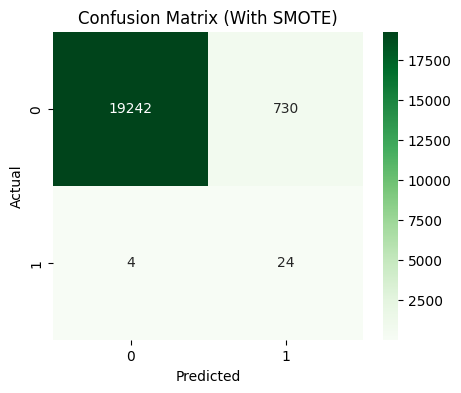

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (With SMOTE)")
plt.show()


In [11]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.96      0.98     19972
           1       0.03      0.86      0.06        28

    accuracy                           0.96     20000
   macro avg       0.52      0.91      0.52     20000
weighted avg       1.00      0.96      0.98     20000



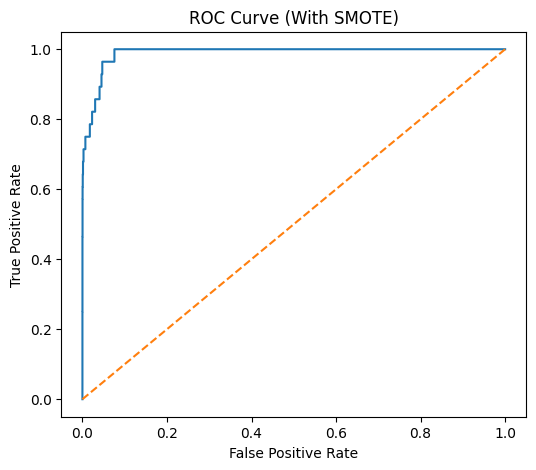

ROC-AUC Score: 0.9895362435981804


In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (With SMOTE)")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


## Conclusion:

After applying SMOTE, the class imbalance problem was resolved by generating synthetic fraud samples.

The Logistic Regression model trained on balanced data showed significant improvement in fraud recall and F1-score compared to the previous experiment.

Although overall accuracy slightly decreased, the model became more effective in identifying fraudulent transactions.

This demonstrates the importance of handling class imbalance in fraud detection systems.
